In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [6]:
df=pd.read_csv("data\creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


[]

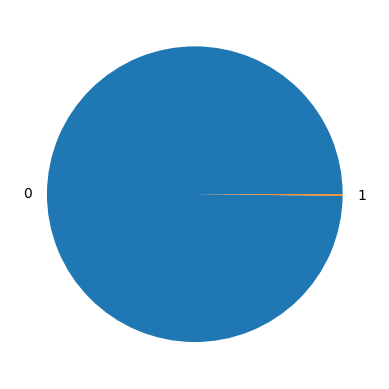

In [7]:
((df.groupby("Class")['Class'].count()/df['Class'].count())*100).plot.pie()
plt.plot()

<Axes: xlabel='Class'>

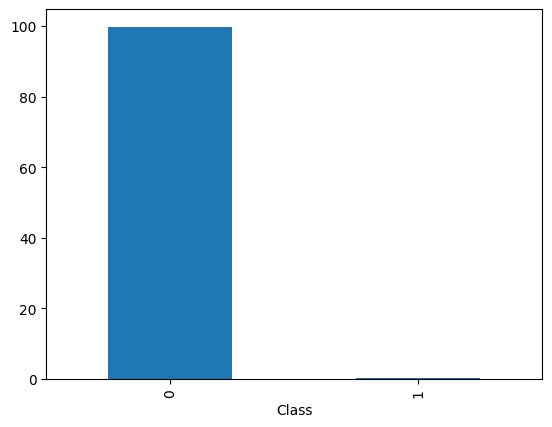

In [8]:
((df.groupby("Class")['Class'].count()/df['Class'].count())*100).plot.bar()

In [9]:
time_h=pd.to_timedelta(df['Time'],unit="s")

In [10]:
df['Hours']=(time_h.dt.components.hours).astype(int)

In [11]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hours
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0


In [15]:
df['Hours'].value_counts()

Hours
21    17703
18    17039
11    16856
20    16756
10    16598
14    16570
15    16461
16    16453
17    16166
9     15838
19    15649
22    15441
12    15420
13    15365
23    10938
8     10276
0      7695
7      7243
1      4220
6      4101
3      3492
2      3328
5      2990
4      2209
Name: count, dtype: int64

In [12]:
df.drop("Time",axis=1,inplace=True)

In [13]:
X=df.drop("Class",axis=1)
Y=df['Class']


In [15]:
Y.head()

0    0
1    0
2    0
3    0
4    0
Name: Class, dtype: int64

In [24]:
from sklearn.linear_model import LogisticRegression,LogisticRegressionCV
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

###### SPLITTING THE DATA INTO TARIN AND TEST DATA


In [18]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,train_size=0.2,random_state=42)

##### Model building

In [19]:
df_results=pd.DataFrame(columns=["mathodology","Model","Acuracy","roc_value","thershold"])

In [42]:
def Plot_confusion_matrix(y_test, pred_test):
    cm=confusion_matrix(y_test,pred_test)
    plt.clf()
    
    plt.imshow(cm,interpolation="nearest",cmap=plt.cm.Accent)
    categoryNames=["Non-Fraslent","Fradalunt"]
    
    plt.title("confusion matrix _Test DATA")
    
    plt.ylabel("true Lable")
    plt.xlabel("predicted lable")
    
    ticks=np.arange(len(categoryNames))
    
    plt.xticks(ticks ,categoryNames,rotation=45)
    
    plt.yticks(ticks,categoryNames)
    s=[["TN","FP"],["FN","TP"]]
    
    for i in range(2):
        for j in range(2):
            
            plt.text(j, i, s[i][j]+"*"+str(cm[i][j]),fontsize=12, 
                    ha="center", 
                    va="center",
                    color="black")
            
            
    plt.show()

##### model creation 


In [23]:
#logistic regression 
from sklearn.model_selection import KFold


In [27]:
num_C= list(np.power(10.0 ,np.arange(-10,10)))

cv_num=KFold(n_splits=10,shuffle=True,random_state=42)

searchCV_l2=LogisticRegressionCV(
    Cs=num_C,
    penalty='l2',
    scoring='roc_auc',
    cv=cv_num
    ,random_state=42,
    max_iter=10000,
    fit_intercept=True
    ,solver='newton-cg',
    tol=4
)

searchCV_l1=LogisticRegressionCV(
    Cs=num_C,
    penalty="l1",
    scoring="roc_auc",
    cv=cv_num,
    random_state=42,
    max_iter=10000,
    fit_intercept=True
    ,solver='liblinear',
    tol=4
    
    )

In [29]:
searchCV_l1.fit(x_train,y_train)
searchCV_l2.fit(x_train,y_train)


print("max auc_roc for l1:",searchCV_l1.scores_[1].mean(axis=0).max())
print("max auc_roc for l2:",searchCV_l2.scores_[1].mean(axis=0).max())


"""print("parameters for l1 regularitions")
print(searchCV_l1.coef_)
print(searchCV_l1.intercept_)
print(searchCV_l1.scores_)


print("parameters for l2 regularitions")
print(searchCV_l2.coef_)
print(searchCV_l2.intercept_)
print(searchCV_l2.scores_)"""


# predict  values

y_pred_l1=searchCV_l1.predict(x_test)
y_pred_l2=searchCV_l2.predict(x_test)


#predicted probabilites

y_pred_l1_probs=searchCV_l1.predict_proba(x_test)[:,1]
y_pred_l2_probs=searchCV_l2.predict_proba(x_test)[:,1]


#accuracy of both l1 and l2 models

accuracy_l1=accuracy_score(y_pred_l1,y_test)
accuracy_l2=accuracy_score(y_pred_l2,y_test)


max auc_roc for l1: 0.972067017341143
max auc_roc for l2: 0.5716111686032888


accuracy_ of logistic model which l1 regularistion : 0.9989686015993259


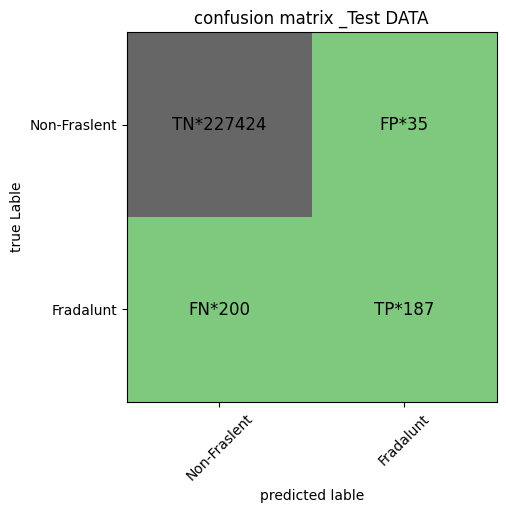

classification_report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227459
           1       0.84      0.48      0.61       387

    accuracy                           1.00    227846
   macro avg       0.92      0.74      0.81    227846
weighted avg       1.00      1.00      1.00    227846



In [43]:
print("accuracy_ of logistic model which l1 regularistion : {0}".format(accuracy_l1))
Plot_confusion_matrix(y_test,y_pred_l1)
print("classification_report")
print(classification_report(y_test,y_pred_l1))


accuracy_ of logistic model which l2 regularistion : 0.9983014843359111


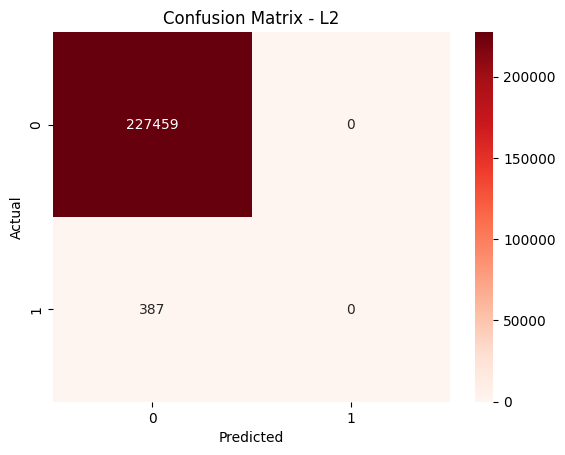

classification_report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227459
           1       0.00      0.00      0.00       387

    accuracy                           1.00    227846
   macro avg       0.50      0.50      0.50    227846
weighted avg       1.00      1.00      1.00    227846



In [39]:
print("accuracy_ of logistic model which l2 regularistion : {0}".format(accuracy_l2))
sns.heatmap(confusion_matrix(y_test,y_pred_l2), annot=True, 
            fmt="d", 
            cmap="Reds")

plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix - L2")
plt.show()
print("classification_report")
print(classification_report(y_test,y_pred_l2))

l1 roc_score 0.867141766060733
l1 treshold is:5.144138821801682e-05


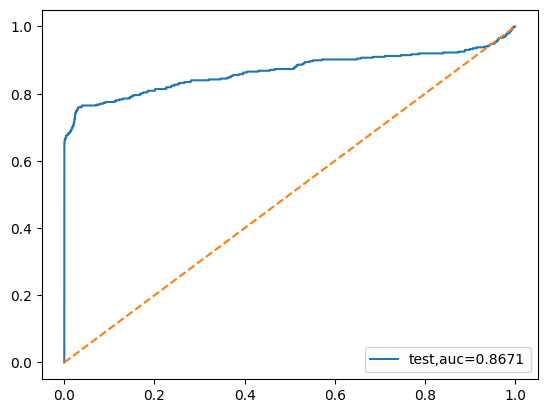

In [ ]:
from sklearn.metrics import r2_score,roc_auc_score,roc_curve,auc
l1_roc_auc_sc=roc_auc_score(y_test,y_pred_l1_probs)

print("l1 roc_score {0}".format(l1_roc_auc_sc))

tpr,fpr,tresholds=roc_curve(y_test,y_pred_l1_probs)
treshold=tresholds[np.argmax(tpr-fpr)]
print("l1 treshold is:{0}".format(treshold))

roc_auc=auc(tpr,fpr)
plt.plot(tpr,fpr,label="test,auc="+str(round(roc_auc,4)))
plt.plot([0,1], [0,1], linestyle="--") 
plt.legend(loc=4)
plt.show()

df_new = pd.DataFrame({
    "Methodology": ["Logistic Regression"],
    "Model": ["Log L1"],
    "Accuracy": [accuracy_l1],
    "ROC_AUC": [l1_roc_auc_sc],
    "Threshold": [treshold]
})



In [51]:
df_new

,Methodology,Model,Accuracy,ROC_AUC,Threshold
0,Logistic Regression,Log L1,0.998969,0.867142,0.000051


l2 roc_score 0.5573948966104384
l2 treshold is:0.030187743117915028


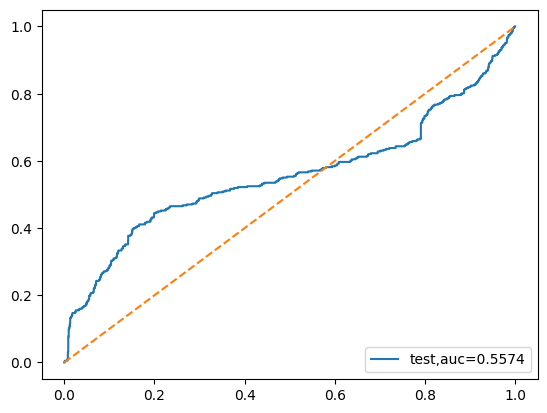

           Methodology   Model  Accuracy   ROC_AUC  Threshold
0  Logistic Regression  Log L2  0.998301  0.557395   0.030188


In [54]:
l2_roc_auc_sc=roc_auc_score(y_test,y_pred_l2_probs)

print("l2 roc_score {0}".format(l2_roc_auc_sc))

tpr,fpr,tresholds=roc_curve(y_test,y_pred_l2_probs)
treshold=tresholds[np.argmax(tpr-fpr)]
print("l2 treshold is:{0}".format(treshold))

roc_auc=auc(tpr,fpr)
plt.plot(tpr,fpr,label="test,auc="+str(round(roc_auc,4)))
plt.plot([0,1], [0,1], linestyle="--") 
plt.legend(loc=4)
plt.show()

df_new = pd.DataFrame({
    "Methodology": ["Logistic Regression"],
    "Model": ["Log L2"],
    "Accuracy": [accuracy_l2],
    "ROC_AUC": [l2_roc_auc_sc],
    "Threshold": [treshold]
})
print(df_new)